# NIDS CNN-LSTM Autoencoder (Colab Ready)

This notebook runs the full pipeline: preprocess → train → evaluate (CIC + CSE).

**Folder layout expected in Google Drive:**
```
MyDrive/nids-cnn-lstm-autoencoder/
  data/raw/CIC-IDS2017/
  data/raw/CSE-CIC-IDS2018/
```

If your dataset is elsewhere, update the paths in `config.yaml`.


Dependency install step in this notebook prefers `uv` (with automatic fallback to `pip`).


> Note: Untuk lokal Windows (DirectML), default konfigurasi project ini memakai CPU (`training.force_cpu: true`) demi stabilitas. Jika ingin akselerasi GPU, gunakan runtime Google Colab GPU.


In [2]:
# Mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('[SKIP] Bukan runtime Colab, mount Drive dilewati.')


[SKIP] Bukan runtime Colab, mount Drive dilewati.


In [2]:
# Move to project root (robust local/colab)
import os
from pathlib import Path

def _is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _is_project_root(p: Path) -> bool:
    return (p / 'requirements.txt').exists() and (p / 'scripts').exists()

def _find_project_root() -> Path:
    env_root = os.environ.get('NIDS_PROJECT_ROOT', '').strip()
    if env_root:
        p = Path(env_root)
        if _is_project_root(p):
            return p

    # quick local candidates
    candidates = [Path.cwd(), *Path.cwd().parents]

    # colab candidates
    mydrive = Path('/content/drive/MyDrive')
    expected = mydrive / 'nids-cnn-lstm-autoencoder'
    expected_colab_nb = mydrive / 'Colab Notebooks' / 'nids-cnn-lstm-autoencoder'
    candidates.extend([expected_colab_nb, expected])

    for c in candidates:
        if _is_project_root(c):
            return c

    # deep scan only in Colab MyDrive
    if _is_colab_runtime() and mydrive.exists():
        for req in mydrive.rglob('requirements.txt'):
            c = req.parent
            if _is_project_root(c):
                return c

    raise FileNotFoundError(
        'Project root not found. Set env NIDS_PROJECT_ROOT or place repo under /content/drive/MyDrive.'
    )

PROJECT_ROOT = _find_project_root().resolve()
os.chdir(PROJECT_ROOT)

# ensure working dirs exist
for rel in [
    'data/raw/CIC-IDS2017',
    'data/raw/CSE-CIC-IDS2018',
    'data/processed',
    'models',
    'results',
]:
    (PROJECT_ROOT / rel).mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CWD:', Path.cwd())
print('CIC CSV count:', len(list((PROJECT_ROOT / 'data/raw/CIC-IDS2017').glob('*.csv'))))
print('CSE CSV count:', len(list((PROJECT_ROOT / 'data/raw/CSE-CIC-IDS2018').glob('*.csv'))))


PROJECT_ROOT: D:\Codingan\Python\nids-cnn-lstm-autoencoder
CWD: D:\Codingan\Python\nids-cnn-lstm-autoencoder
CIC CSV count: 8
CSE CSV count: 10


In [3]:
# Install dependencies (Colab-aware: local pins vs colab runtime)
import sys
import shutil
import subprocess
from pathlib import Path

def _is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

req = Path('requirements.txt').resolve()
if not req.exists():
    raise FileNotFoundError(f'requirements.txt not found at {req}')

def _run(cmd):
    print('[CMD]', ' '.join(cmd))
    subprocess.run(cmd, check=True)

def _install_with_pip(req_path: Path):
    _run([sys.executable, '-m', 'pip', 'install', '-r', str(req_path)])

def _install_with_uv(req_path: Path):
    _run(['uv', 'pip', 'install', '-r', str(req_path)])

is_colab = _is_colab_runtime()

# In Colab, avoid Windows-local pins (tensorflow==2.10.1, numpy<2)
effective_req = req
if is_colab:
    filtered = []
    for line in req.read_text(encoding='utf-8').splitlines():
        s = line.strip()
        if not s or s.startswith('#'):
            filtered.append(line)
            continue
        low = s.lower()
        if low.startswith('tensorflow') or low.startswith('numpy'):
            continue
        filtered.append(line)

    effective_req = Path('/tmp/requirements_colab.txt')
    effective_req.write_text('\n'.join(filtered) + '\n', encoding='utf-8')
    print('[INFO] Colab mode: using filtered requirements (skip local tensorflow/numpy pins).')

used_uv = False
if shutil.which('uv'):
    try:
        _install_with_uv(effective_req)
        used_uv = True
    except subprocess.CalledProcessError:
        print('[WARN] uv install failed, falling back to pip...')

if not used_uv:
    try:
        if not shutil.which('uv'):
            _run([sys.executable, '-m', 'pip', 'install', '-q', 'uv'])
            try:
                _install_with_uv(effective_req)
                used_uv = True
            except subprocess.CalledProcessError:
                print('[WARN] uv still failed after install, using pip...')
    except subprocess.CalledProcessError:
        print('[WARN] failed to install uv, using pip...')

if not used_uv:
    _install_with_pip(effective_req)

# Ensure TensorFlow exists in Colab after filtered install
if is_colab:
    try:
        import tensorflow as tf  # noqa: F401
        print('[INFO] TensorFlow already available in Colab.')
    except Exception:
        print('[INFO] TensorFlow not found, installing latest compatible build...')
        _run([sys.executable, '-m', 'pip', 'install', 'tensorflow'])


[CMD] uv pip install -r D:\Codingan\Python\nids-cnn-lstm-autoencoder\requirements.txt


In [4]:
# Optional: Show GPU (detailed diagnostics)
import os
import sys
import time
import shlex
import subprocess
import importlib.util
from pathlib import Path

import tensorflow as tf

print('Python executable :', sys.executable)
print('TensorFlow        :', tf.__version__)
print('Built with CUDA   :', tf.test.is_built_with_cuda())
print('Built with GPU sup:', tf.test.is_built_with_gpu_support())
print('CUDA_VISIBLE_DEVICES =', os.environ.get('CUDA_VISIBLE_DEVICES', '<not-set>'))
print('DirectML plugin   :', importlib.util.find_spec('tensorflow_directml_plugin') is not None)

physical_gpus = tf.config.list_physical_devices('GPU')
logical_gpus = tf.config.list_logical_devices('GPU')

print('Physical GPU list :', physical_gpus)
print('Logical GPU list  :', logical_gpus)

if not physical_gpus:
    print('[WARN] TensorFlow tidak mendeteksi GPU dari environment/kernel ini.')
    print('[HINT] Pastikan kernel notebook memakai env yang benar, lalu restart kernel.')
    print('[HINT] Cek paket aktif: tensorflow, tensorflow-intel, tensorflow-directml-plugin.')
    print('[HINT] Di Windows, nvidia-smi bisa terdeteksi tapi TensorFlow tetap CPU-only jika backend tidak cocok.')

def _fmt_duration(seconds: float) -> str:
    sec = max(0, int(seconds))
    h, rem = divmod(sec, 3600)
    m, s = divmod(rem, 60)
    if h > 0:
        return f'{h}h {m:02d}m {s:02d}s'
    if m > 0:
        return f'{m}m {s:02d}s'
    return f'{s}s'

def _normalize_cmd(cmd: str):
    parts = shlex.split(cmd, posix=False)
    if parts and parts[0].lower() == 'python':
        parts[0] = sys.executable
    return parts

def run_cmd_stream(title: str, cmd: str, stage_no: int | None = None, total_stages: int | None = None):
    if stage_no is not None and total_stages is not None:
        start_pct = ((stage_no - 1) / total_stages) * 100
        end_pct = (stage_no / total_stages) * 100
        print(f'[STAGE {stage_no}/{total_stages}] {title} started | global progress {start_pct:.0f}% -> {end_pct:.0f}%')
    else:
        print(f'[STAGE] {title} started')

    args = _normalize_cmd(cmd)
    print('[CMD]', ' '.join(args))
    t0 = time.time()

    proc = subprocess.Popen(
        args,
        cwd=str(PROJECT_ROOT),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    last_line = ''
    for line in proc.stdout:
        print(line, end='')
        last_line = line.strip()

    ret = proc.wait()
    print(f'\n[EXIT CODE] {ret}')
    if ret != 0:
        raise RuntimeError(f"{title} failed (exit={ret}). Last log line: {last_line}")

    print(f'[DONE] {title} finished in {_fmt_duration(time.time() - t0)}')

def run_cmds_stream(title: str, commands, stage_no: int | None = None, total_stages: int | None = None):
    if isinstance(commands, str):
        commands = [commands]

    if stage_no is not None and total_stages is not None:
        start_pct = ((stage_no - 1) / total_stages) * 100
        end_pct = (stage_no / total_stages) * 100
        print(f'[STAGE {stage_no}/{total_stages}] {title} started | global progress {start_pct:.0f}% -> {end_pct:.0f}%')
    else:
        print(f'[STAGE] {title} started')

    t0 = time.time()
    for i, cmd in enumerate(commands, start=1):
        print(f'[PROGRESS] command {i}/{len(commands)}')
        run_cmd_stream(f'{title} :: command {i}', cmd)

    print(f'[DONE] Stage ({title}) finished in {_fmt_duration(time.time() - t0)}')



Python executable : c:\Users\nitro\.conda\envs\nids-tf210gpu\python.exe
TensorFlow        : 2.10.1
Built with CUDA   : True
Built with GPU sup: True
CUDA_VISIBLE_DEVICES = <not-set>
DirectML plugin   : False
Physical GPU list : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPU list  : [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


## Optional: Download Dataset from Kaggle (Colab + Local)
Cell ini **opsional** dan default-nya OFF.

Default output disimpan ke folder lokal project: `data/raw/CIC-IDS2017` dan `data/raw/CSE-CIC-IDS2018`.
Token Kaggle bisa dari `./kaggle.json`, `PROJECT_ROOT/kaggle.json`, `~/.kaggle/kaggle.json`, atau env `KAGGLE_USERNAME` + `KAGGLE_KEY`.


In [ ]:
# Optional Kaggle downloader (Colab + Local output)
from pathlib import Path
import sys
import os
import shutil
import subprocess
import zipfile

ENABLE_KAGGLE_DOWNLOAD = False  # ubah ke True kalau ingin download
OVERWRITE_EXISTING = True      # True kalau ingin timpa file lama
DOWNLOAD_TO_PROJECT_RAW = True # True => simpan ke PROJECT_ROOT/data/raw
CUSTOM_RAW_BASE_DIR = ''       # isi path lokal kalau DOWNLOAD_TO_PROJECT_RAW=False

def _is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _run(cmd):
    print('[CMD]', ' '.join(cmd))
    subprocess.run(cmd, check=True)

if not ENABLE_KAGGLE_DOWNLOAD:
    print('[SKIP] ENABLE_KAGGLE_DOWNLOAD=False. Aktifkan jika ingin download dataset.')
else:
    project_root = PROJECT_ROOT if 'PROJECT_ROOT' in globals() else Path(os.getcwd())

    if DOWNLOAD_TO_PROJECT_RAW:
        raw_base = project_root / 'data' / 'raw'
    else:
        if not str(CUSTOM_RAW_BASE_DIR).strip():
            raise ValueError('CUSTOM_RAW_BASE_DIR wajib diisi saat DOWNLOAD_TO_PROJECT_RAW=False')
        raw_base = Path(CUSTOM_RAW_BASE_DIR).expanduser().resolve()

    raw_cic = raw_base / 'CIC-IDS2017'
    raw_cse = raw_base / 'CSE-CIC-IDS2018'
    raw_cic.mkdir(parents=True, exist_ok=True)
    raw_cse.mkdir(parents=True, exist_ok=True)

    _run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'])

    # Setup Kaggle auth: prefer token file, fallback to env vars
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    token_target = kaggle_dir / 'kaggle.json'

    token_candidates = [
        Path.cwd() / 'kaggle.json',
        project_root / 'kaggle.json',
        token_target,
        Path('/content/drive/MyDrive/Colab Notebooks/kaggle.json'),
        Path('/content/drive/MyDrive/kaggle.json'),
    ]

    chosen_token = next((p for p in token_candidates if p.exists()), None)
    if chosen_token is not None:
        if chosen_token.resolve() != token_target.resolve():
            shutil.copy2(chosen_token, token_target)
        os.chmod(token_target, 0o600)
        print(f'[INFO] Kaggle token file: {chosen_token}')
    else:
        user = os.environ.get('KAGGLE_USERNAME', '').strip()
        key = os.environ.get('KAGGLE_KEY', '').strip()
        if not (user and key):
            raise FileNotFoundError(
                'Kaggle token tidak ditemukan. Sediakan kaggle.json (lokal/project/~/.kaggle) '
                'atau set env KAGGLE_USERNAME dan KAGGLE_KEY.'
            )
        print('[INFO] Menggunakan kredensial Kaggle dari environment variables.')

    tmp = project_root / 'data' / 'raw' / '_kaggle_tmp'
    tmp.mkdir(parents=True, exist_ok=True)

    def download_and_extract(dataset_slug: str, zip_name: str, out_dir: Path):
        zip_path = tmp / zip_name
        _run(['kaggle', 'datasets', 'download', '-d', dataset_slug, '-p', str(tmp), '--force'])
        if not zip_path.exists():
            # fallback: kaggle kadang pakai nama file berdasarkan slug
            candidates = sorted(tmp.glob('*.zip'), key=lambda x: x.stat().st_mtime, reverse=True)
            if not candidates:
                raise FileNotFoundError(f'Zip tidak ditemukan untuk {dataset_slug}')
            zip_path = candidates[0]
        extract_dir = tmp / (zip_path.stem + '_extract')
        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_dir)

        csvs = sorted(extract_dir.rglob('*.csv'))
        copied = 0
        for f in csvs:
            dst = out_dir / f.name
            if dst.exists() and not OVERWRITE_EXISTING:
                continue
            shutil.copy2(f, dst)
            copied += 1
        print(f'[DONE] {dataset_slug}: copied {copied} CSV files to {out_dir}')

    # CIC-IDS2017 mirror (Kaggle)
    download_and_extract('chethuhn/network-intrusion-dataset', 'network-intrusion-dataset.zip', raw_cic)

    # CSE-CIC-IDS2018 mirror (Kaggle)
    download_and_extract('solarmainframe/ids-intrusion-csv', 'ids-intrusion-csv.zip', raw_cse)

    print('[SUMMARY] RAW BASE:', raw_base)
    print('[SUMMARY] CIC CSV:', len(list(raw_cic.glob('*.csv'))))
    print('[SUMMARY] CSE CSV:', len(list(raw_cse.glob('*.csv'))))


[CMD] c:\Users\nitro\.conda\envs\nids-tf210gpu\python.exe -m pip install -q kaggle
[INFO] Kaggle token file: D:\Codingan\Python\nids-cnn-lstm-autoencoder\kaggle.json
[CMD] kaggle datasets download -d chethuhn/network-intrusion-dataset -p D:\Codingan\Python\nids-cnn-lstm-autoencoder\data\raw\_kaggle_tmp --force
[DONE] chethuhn/network-intrusion-dataset: copied 8 CSV files to D:\Codingan\Python\nids-cnn-lstm-autoencoder\data\raw\CIC-IDS2017
[CMD] kaggle datasets download -d solarmainframe/ids-intrusion-csv -p D:\Codingan\Python\nids-cnn-lstm-autoencoder\data\raw\_kaggle_tmp --force
[DONE] solarmainframe/ids-intrusion-csv: copied 10 CSV files to D:\Codingan\Python\nids-cnn-lstm-autoencoder\data\raw\CSE-CIC-IDS2018
[SUMMARY] RAW BASE: D:\Codingan\Python\nids-cnn-lstm-autoencoder\data\raw
[SUMMARY] CIC CSV: 8
[SUMMARY] CSE CSV: 10


## 1) Preprocess
Generates (default sharded mode):
- data/processed/shards/cic/train/*.npz + manifest.json
- data/processed/shards/cic/val/*.npz + manifest.json
- data/processed/shards/cic/test/*.npz + manifest.json
- data/processed/shards/cse/test/*.npz + manifest.json
- data/processed/scaler.pkl
- data/processed/feature_columns.json
- data/processed/feature_filter_report.json (if feature filter enabled)


### Experiment Config (Preprocess + Evaluation)
Set eksperimen langsung dari notebook agar sinkron dengan pipeline terbaru:
- Preprocess: scaler + feature filter (NZV/correlation)
- Evaluation: zero-shot / few-shot + threshold method


In [ ]:
# Experiment config toggles (updates config.yaml)
import yaml
from pathlib import Path

# --- Preprocess toggles ---
PREPROCESS_SCALER = 'robust'          # 'standard' | 'minmax' | 'robust'
SCALER_FIT_MODE = 'full_benign'       # 'auto' | 'stream_partial' | 'full_benign'
ENABLE_NZV_FILTER = True
NZV_THRESHOLD = 1e-6
ENABLE_CORR_FILTER = True
CORR_THRESHOLD = 0.95
FILTER_SAMPLE_ROWS_LIMIT = 100000

# --- Training toggles ---
LR_SCHEDULER = 'reduce_on_plateau'    # 'reduce_on_plateau' | 'cosine' | 'none'
CLIPNORM = 1.0                        # set None to disable
EARLY_STOP_PATIENCE = 20
RESTORE_BEST_WEIGHTS = True

# --- Evaluation toggles ---
EVAL_MODE = 'zero_shot'               # 'zero_shot' | 'few_shot'
THRESHOLD_METHOD = 'percentile'       # 'percentile' | 'target_percentile' | 'target_gaussian'
THRESHOLD_K_SIGMA = 2.5
FEW_SHOT_BENIGN_FRAC = 0.01
FEW_SHOT_MAX_SAMPLES = 50000
FEW_SHOT_FINETUNE_EPOCHS = 0
FEW_SHOT_FINETUNE_LR = 5e-4
FEW_SHOT_FINETUNE_BATCH = 256

config_path = Path('config.yaml')
with open(config_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

pp = cfg.setdefault('preprocess', {})
pp['scaler'] = PREPROCESS_SCALER
pp['scaler_fit_mode'] = SCALER_FIT_MODE
ff = pp.setdefault('feature_filter', {})
ff['enable_nzv'] = bool(ENABLE_NZV_FILTER)
ff['nzv_threshold'] = float(NZV_THRESHOLD)
ff['enable_corr'] = bool(ENABLE_CORR_FILTER)
ff['corr_threshold'] = float(CORR_THRESHOLD)
ff['sample_rows_limit'] = int(FILTER_SAMPLE_ROWS_LIMIT)

tr = cfg.setdefault('training', {})
tr['lr_scheduler'] = LR_SCHEDULER
tr['early_stopping_patience'] = int(EARLY_STOP_PATIENCE)
tr['restore_best_weights'] = bool(RESTORE_BEST_WEIGHTS)
tr['clipnorm'] = None if CLIPNORM is None else float(CLIPNORM)

ev = cfg.setdefault('evaluation', {})
ev['mode'] = EVAL_MODE
ev['threshold_method'] = THRESHOLD_METHOD
ev['threshold_k_sigma'] = float(THRESHOLD_K_SIGMA)
ev['few_shot_benign_frac'] = float(FEW_SHOT_BENIGN_FRAC)
ev['few_shot_max_samples'] = int(FEW_SHOT_MAX_SAMPLES)
ev['few_shot_finetune_epochs'] = int(FEW_SHOT_FINETUNE_EPOCHS)
ev['few_shot_finetune_lr'] = float(FEW_SHOT_FINETUNE_LR)
ev['few_shot_finetune_batch_size'] = int(FEW_SHOT_FINETUNE_BATCH)

with open(config_path, 'w', encoding='utf-8') as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print('[DONE] config.yaml updated')
print('  preprocess.scaler =', pp['scaler'])
print('  preprocess.scaler_fit_mode =', pp['scaler_fit_mode'])
print('  preprocess.feature_filter =', ff)
print('  training.lr_scheduler =', tr['lr_scheduler'])
print('  training.clipnorm =', tr['clipnorm'])
print('  evaluation.mode =', ev['mode'])
print('  evaluation.threshold_method =', ev['threshold_method'])




In [ ]:
run_cmd_stream(
    title='Preprocess',
    cmd='python scripts/preprocess.py --config config.yaml',
    stage_no=1,
    total_stages=4,
)



## 2) Train Hybrid CNN-LSTM Autoencoder


In [ ]:
run_cmd_stream(
    title='Train Hybrid CNN-LSTM AE',
    cmd='python scripts/train_cnn_lstm_ae.py --config config.yaml',
    stage_no=2,
    total_stages=4,
)



## 3) Evaluate (CIC + CSE)
Outputs metrics + plots in `results/` using threshold logic from config.
Support mode:
- `zero_shot`: threshold dari source validation (atau source-based method)
- `few_shot`: adaptasi benign target + optional fine-tuning unsupervised

Example outputs for `--tag cnn_lstm`:
- results/metrics/cnn_lstm_cic_metrics.json
- results/metrics/cnn_lstm_cse_metrics.json
- results/metrics/cnn_lstm_generalization_gap.json
- results/plots/cnn_lstm/roc_cic.png
- results/plots/cnn_lstm/roc_cse.png


In [ ]:
# Evaluate helper: single mode or dual mode (zero-shot + few-shot)
import yaml
from pathlib import Path

RUN_BOTH_MODES = False
BASE_TAG = 'cnn_lstm'
MODEL_PATH = 'models/cnn_lstm_ae/best_model.keras'

config_path = Path('config.yaml')


def _set_eval_mode(mode: str, threshold_method: str):
    with open(config_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
    ev = cfg.setdefault('evaluation', {})
    ev['mode'] = mode
    ev['threshold_method'] = threshold_method
    with open(config_path, 'w', encoding='utf-8') as f:
        yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)
    print(f"[CONFIG] evaluation.mode={mode} threshold_method={threshold_method}")


if RUN_BOTH_MODES:
    # zero-shot baseline
    _set_eval_mode('zero_shot', 'percentile')
    run_cmd_stream(
        title='Evaluate Zero-Shot',
        cmd=f'python scripts/eval_metrics.py --config config.yaml --model {MODEL_PATH} --tag {BASE_TAG}_zero_shot',
        stage_no=3,
        total_stages=4,
    )

    # few-shot adaptation
    _set_eval_mode('few_shot', 'target_percentile')
    run_cmd_stream(
        title='Evaluate Few-Shot',
        cmd=f'python scripts/eval_metrics.py --config config.yaml --model {MODEL_PATH} --tag {BASE_TAG}_few_shot',
        stage_no=3,
        total_stages=4,
    )
else:
    run_cmd_stream(
        title='Evaluate (CIC + CSE)',
        cmd=f'python scripts/eval_metrics.py --config config.yaml --model {MODEL_PATH} --tag {BASE_TAG}',
        stage_no=3,
        total_stages=4,
    )



### Compare Zero-Shot vs Few-Shot (Optional)
Jalankan cell ini setelah kamu punya kedua output tag:
- `*_zero_shot`
- `*_few_shot`


In [ ]:
# Compare metrics helper (zero-shot vs few-shot)
import json
from pathlib import Path

BASE_TAG = 'cnn_lstm'  # change if needed
METRICS_DIR = Path('results/metrics')


def _load_json(path: Path):
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def _fmt(v):
    if v is None:
        return 'None'
    return f'{v:.4f}' if isinstance(v, (int, float)) else str(v)


def _delta(a, b):
    if a is None or b is None:
        return None
    return b - a

zero_cic = _load_json(METRICS_DIR / f'{BASE_TAG}_zero_shot_cic_metrics.json')
zero_cse = _load_json(METRICS_DIR / f'{BASE_TAG}_zero_shot_cse_metrics.json')
zero_gap = _load_json(METRICS_DIR / f'{BASE_TAG}_zero_shot_generalization_gap.json')

few_cic = _load_json(METRICS_DIR / f'{BASE_TAG}_few_shot_cic_metrics.json')
few_cse = _load_json(METRICS_DIR / f'{BASE_TAG}_few_shot_cse_metrics.json')
few_gap = _load_json(METRICS_DIR / f'{BASE_TAG}_few_shot_generalization_gap.json')

required = [zero_cic, zero_cse, zero_gap, few_cic, few_cse, few_gap]
if any(x is None for x in required):
    print('[WARN] Missing one or more metrics files.')
    print('Expected files:')
    for p in [
        METRICS_DIR / f'{BASE_TAG}_zero_shot_cic_metrics.json',
        METRICS_DIR / f'{BASE_TAG}_zero_shot_cse_metrics.json',
        METRICS_DIR / f'{BASE_TAG}_zero_shot_generalization_gap.json',
        METRICS_DIR / f'{BASE_TAG}_few_shot_cic_metrics.json',
        METRICS_DIR / f'{BASE_TAG}_few_shot_cse_metrics.json',
        METRICS_DIR / f'{BASE_TAG}_few_shot_generalization_gap.json',
    ]:
        print(' -', p)
else:
    rows = [
        ('CIC F1', zero_cic.get('f1'), few_cic.get('f1')),
        ('CIC FPR', zero_cic.get('fpr'), few_cic.get('fpr')),
        ('CSE F1', zero_cse.get('f1'), few_cse.get('f1')),
        ('CSE FPR', zero_cse.get('fpr'), few_cse.get('fpr')),
        ('CSE AUC', zero_cse.get('roc_auc'), few_cse.get('roc_auc')),
        ('F1 Gap', zero_gap.get('f1_gap'), few_gap.get('f1_gap')),
        ('AUC Gap', zero_gap.get('auc_gap'), few_gap.get('auc_gap')),
        ('Accuracy Gap', zero_gap.get('accuracy_gap'), few_gap.get('accuracy_gap')),
    ]

    print(f'Comparison for BASE_TAG={BASE_TAG}')
    print('-' * 72)
    print(f"{'Metric':<18} {'Zero-Shot':>12} {'Few-Shot':>12} {'Delta':>12}")
    print('-' * 72)
    for name, z, f in rows:
        d = _delta(z, f)
        print(f"{name:<18} {_fmt(z):>12} {_fmt(f):>12} {_fmt(d):>12}")

    print('-' * 72)
    if zero_cse.get('fpr') is not None and few_cse.get('fpr') is not None:
        if few_cse['fpr'] < zero_cse['fpr']:
            print('[INFO] Few-shot improves CSE FPR (lower is better).')
        elif few_cse['fpr'] > zero_cse['fpr']:
            print('[INFO] Few-shot worsens CSE FPR.')
        else:
            print('[INFO] CSE FPR unchanged.')



### Visualisasi Hasil Training & Evaluasi
Jalankan cell ini **setelah** evaluasi selesai untuk menampilkan grafik secara inline di notebook.

Yang akan ditampilkan:
- Kurva training (`train_loss` vs `val_loss`)
- Ringkasan metrik CIC, CSE, dan generalization gap
- Plot ROC, confusion matrix, dan distribusi reconstruction error (CIC & CSE)

> Jika plot belum muncul, pastikan Cell evaluasi sebelumnya sudah sukses (`EXIT CODE 0`) dan file output tersimpan di folder `results/`.

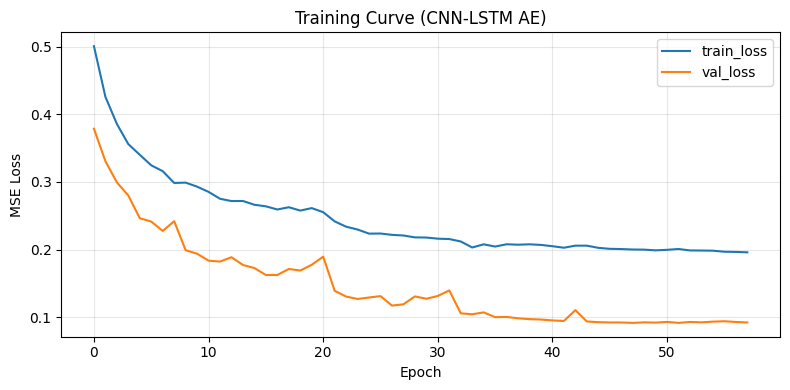

[METRICS SUMMARY]
CIC | acc=0.8132 prec=0.9553 rec=0.6256 f1=0.7561 auc=0.8158 fpr=0.0252
CSE | acc=0.6514 prec=0.6612 rec=0.6977 f1=0.6790 auc=0.6574 fpr=0.4005
GAP | f1_gap=0.0771 auc_gap=0.1583 acc_gap=0.1618


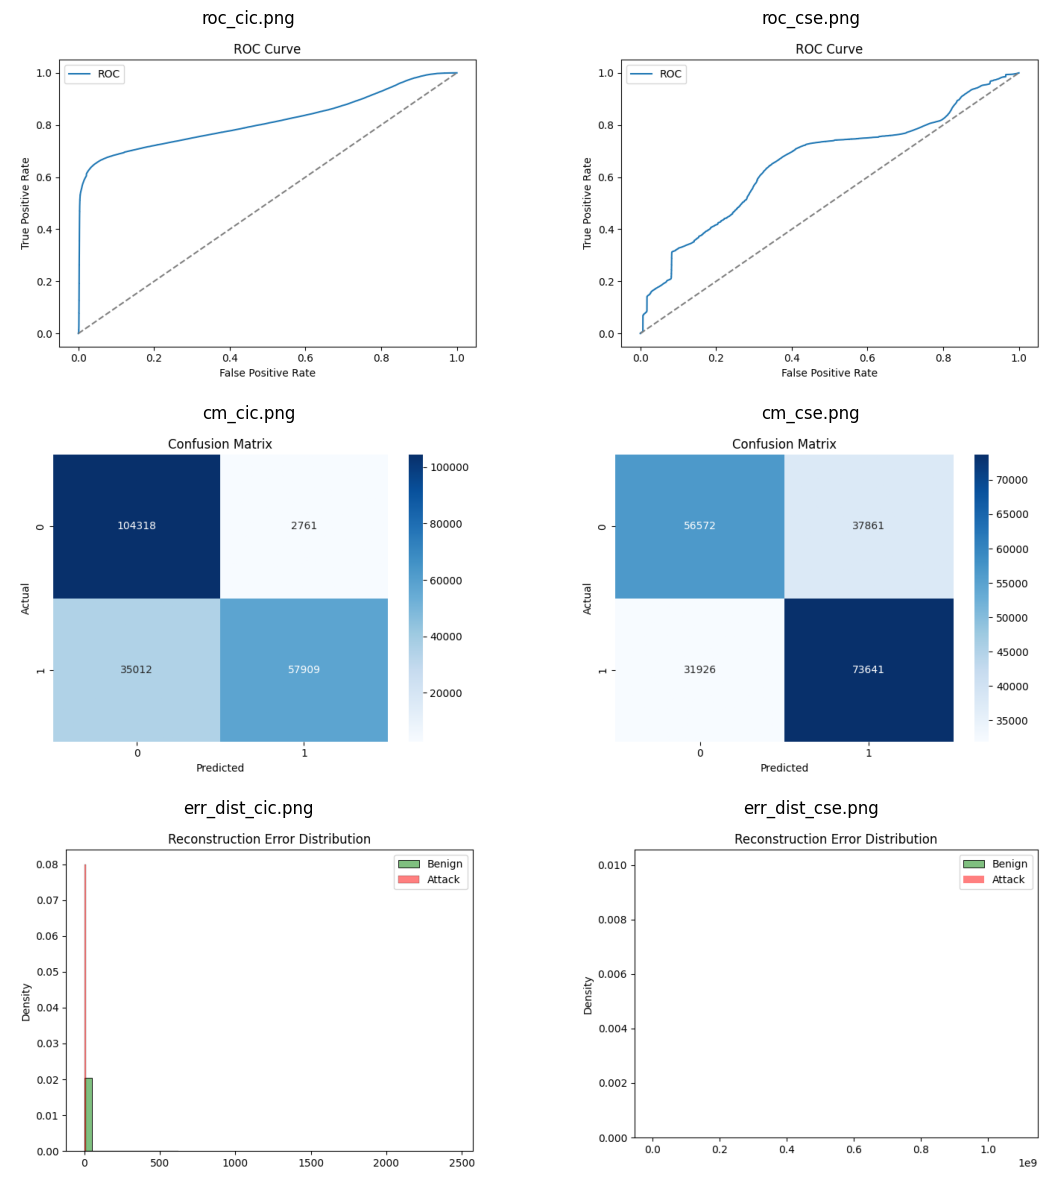

In [6]:
# Show training/evaluation charts inline
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if 'PROJECT_ROOT' not in globals():
    raise NameError('PROJECT_ROOT not defined. Run earlier cells first.')

history_path = PROJECT_ROOT / 'results' / 'logs' / 'cnn_lstm_history.json'
metrics_dir = PROJECT_ROOT / 'results' / 'metrics'
plots_dir = PROJECT_ROOT / 'results' / 'plots' / 'cnn_lstm'

if history_path.exists():
    hist = json.loads(history_path.read_text(encoding='utf-8'))
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])
    if loss and val_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(loss, label='train_loss')
        plt.plot(val_loss, label='val_loss')
        plt.title('Training Curve (CNN-LSTM AE)')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

def _read_json(p: Path):
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else None

cic = _read_json(metrics_dir / 'cnn_lstm_cic_metrics.json')
cse = _read_json(metrics_dir / 'cnn_lstm_cse_metrics.json')
gap = _read_json(metrics_dir / 'cnn_lstm_generalization_gap.json')

print('[METRICS SUMMARY]')
if cic:
    print('CIC | acc={:.4f} prec={:.4f} rec={:.4f} f1={:.4f} auc={} fpr={:.4f}'.format(
        cic.get('accuracy', 0.0), cic.get('precision', 0.0), cic.get('recall', 0.0),
        cic.get('f1', 0.0),
        'None' if cic.get('roc_auc') is None else f"{cic['roc_auc']:.4f}",
        cic.get('fpr', 0.0),
    ))
if cse:
    print('CSE | acc={:.4f} prec={:.4f} rec={:.4f} f1={:.4f} auc={} fpr={:.4f}'.format(
        cse.get('accuracy', 0.0), cse.get('precision', 0.0), cse.get('recall', 0.0),
        cse.get('f1', 0.0),
        'None' if cse.get('roc_auc') is None else f"{cse['roc_auc']:.4f}",
        cse.get('fpr', 0.0),
    ))
if gap:
    print('GAP | f1_gap={:.4f} auc_gap={:.4f} acc_gap={:.4f}'.format(
        gap.get('f1_gap', 0.0), gap.get('auc_gap', 0.0), gap.get('accuracy_gap', 0.0),
    ))

plot_files = [
    plots_dir / 'roc_cic.png',
    plots_dir / 'roc_cse.png',
    plots_dir / 'cm_cic.png',
    plots_dir / 'cm_cse.png',
    plots_dir / 'err_dist_cic.png',
    plots_dir / 'err_dist_cse.png',
]

available = [p for p in plot_files if p.exists()]
if not available:
    print('[INFO] Plot files belum ditemukan. Jalankan evaluasi dulu (Cell 13).')
else:
    cols = 2
    rows = (len(available) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, p in enumerate(available):
        axes[i].imshow(mpimg.imread(p))
        axes[i].set_title(p.name)
        axes[i].axis('off')

    for j in range(len(available), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## 4) Optional: Train LSTM Autoencoder Baseline


In [ ]:
run_cmds_stream(
    title='Baseline LSTM AE',
    commands=[
        'python scripts/train_lstm_ae.py --config config.yaml',
        'python scripts/eval_metrics.py --config config.yaml --model models/lstm_ae/best_model.keras --tag lstm_ae',
    ],
    stage_no=4,
    total_stages=4,
)

